In [ ]:
# Unzip the Dataset
!unzip archive.zip

Archive:  archive.zip
  inflating: Resume/Resume.csv       
  inflating: data/data/ACCOUNTANT/10554236.pdf  
  inflating: data/data/ACCOUNTANT/10674770.pdf  
  inflating: data/data/ACCOUNTANT/11163645.pdf  
  inflating: data/data/ACCOUNTANT/11759079.pdf  
  inflating: data/data/ACCOUNTANT/12065211.pdf  
  inflating: data/data/ACCOUNTANT/12202337.pdf  
  inflating: data/data/ACCOUNTANT/12338274.pdf  
  inflating: data/data/ACCOUNTANT/12442909.pdf  
  inflating: data/data/ACCOUNTANT/12780508.pdf  
  inflating: data/data/ACCOUNTANT/12802330.pdf  
  inflating: data/data/ACCOUNTANT/13072019.pdf  
  inflating: data/data/ACCOUNTANT/13130984.pdf  
  inflating: data/data/ACCOUNTANT/13294301.pdf  
  inflating: data/data/ACCOUNTANT/13491889.pdf  
  inflating: data/data/ACCOUNTANT/13701259.pdf  
  inflating: data/data/ACCOUNTANT/14055988.pdf  
  inflating: data/data/ACCOUNTANT/14126433.pdf  
  inflating: data/data/ACCOUNTANT/14224370.pdf  
  inflating: data/data/ACCOUNTANT/14449423.pdf  
  inflati

In [ ]:
# Import Libraries
import pandas as pd
import os

In [ ]:
# Read the CSV File
df = pd.read_csv("/content/Resume/Resume.csv")

In [ ]:
# View the Dataset
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
# Check the Column Names
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [ ]:
# Chech Dataset Size
print(df.shape)

(2484, 4)


In [ ]:
# Check for Missing Values
print(df.isnull().sum())

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [ ]:
# Check the categories
for category in df["Category"].unique():
    print(category)

HR
DESIGNER
INFORMATION-TECHNOLOGY
TEACHER
ADVOCATE
BUSINESS-DEVELOPMENT
HEALTHCARE
FITNESS
AGRICULTURE
BPO
SALES
CONSULTANT
DIGITAL-MEDIA
AUTOMOBILE
CHEF
FINANCE
APPAREL
ENGINEERING
ACCOUNTANT
CONSTRUCTION
PUBLIC-RELATIONS
BANKING
ARTS
AVIATION


In [ ]:
# Text preprocessing
# Install required libraries
!pip install nltk

In [ ]:
# Import Libraries
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [ ]:
# Download NLTK Data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# View One Resume Before Cleaning
print(df["Resume_str"][0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

In [ ]:
# Create Stopwords & Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
# Create the Cleaning Function

def clean_resume(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Remove stop words
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [ ]:
# Install Required Libraries
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# Apply Cleaning to Every Resume
df["Cleaned_Resume"] = df["Resume_str"].apply(clean_resume)

In [ ]:
# Compare Before & After
print("Original Resume:\n")
print(df["Resume_str"][0])

print("\n" + "="*80 + "\n")

print("Cleaned Resume:\n")
print(df["Cleaned_Resume"][0])

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory c

In [ ]:
# View the Updated Dataset
df.head()

,ID,Resume_str,Resume_html,Category,Cleaned_Resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administratormarketing associate hr adminis...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist u hr operation summary versatile...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary year experience recruiting...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlight hr skill hr departm...


In [ ]:
# Check Missing Values Again
print(df.isnull().sum())

ID                0
Resume_str        0
Resume_html       0
Category          0
Cleaned_Resume    0
dtype: int64


In [ ]:
# Keep Only the Required Columns
cleaned_df = df[["Cleaned_Resume", "Category"]]

In [ ]:
# View the Final Dataset
cleaned_df.head()

,Cleaned_Resume,Category
0,hr administratormarketing associate hr adminis...,HR
1,hr specialist u hr operation summary versatile...,HR
2,hr director summary year experience recruiting...,HR
3,hr specialist summary dedicated driven dynamic...,HR
4,hr manager skill highlight hr skill hr departm...,HR


In [ ]:
# Save the Cleaned Dataset
cleaned_df.to_csv("cleaned_resume.csv", index=False)

In [ ]:
# Download the Cleaned Dataset
from google.colab import files

files.download("cleaned_resume.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

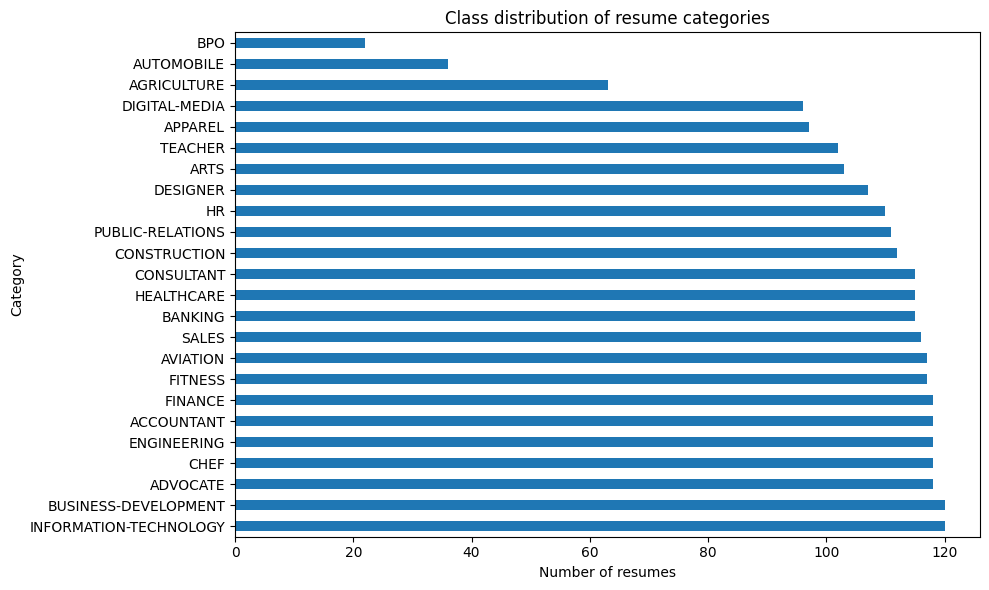

In [ ]:
# Exploratory Data Analysis (EDA)
# Visualize the Distribution of Resume Categories

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
df['Category'].value_counts().plot(kind='barh')
plt.title('Class distribution of resume categories')
plt.xlabel('Number of resumes')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

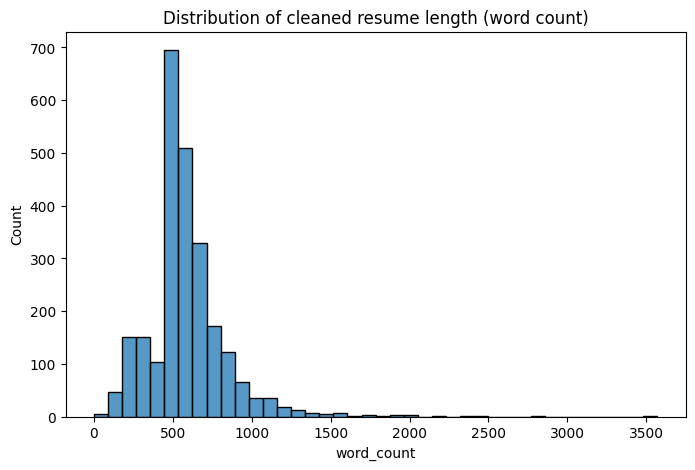

count    2484.000000
mean      586.855475
std       262.343683
min         0.000000
25%       477.000000
50%       547.500000
75%       678.000000
max      3571.000000
Name: word_count, dtype: float64


In [ ]:
# Analyze the Distribution of Resume Lengths

df['word_count'] = df['Cleaned_Resume'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=40)
plt.title('Distribution of cleaned resume length (word count)')
plt.savefig('length_distribution.png')
plt.show()
print(df['word_count'].describe())

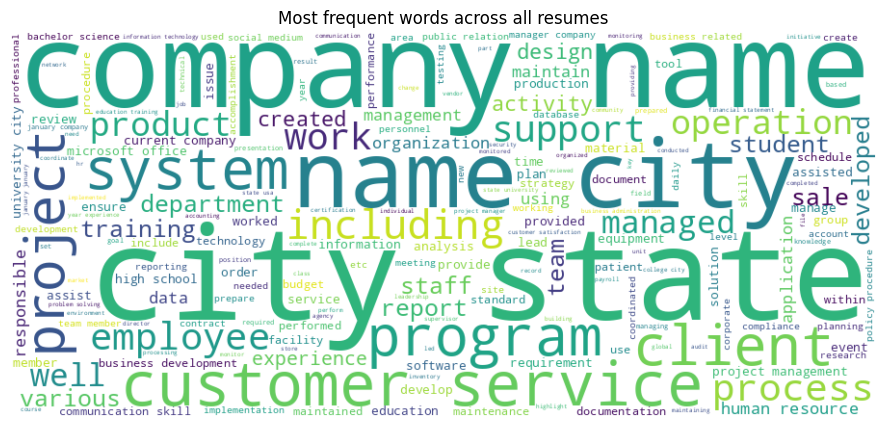

In [ ]:
# Generate a Word Cloud of Resume Text

!pip install -q wordcloud
from wordcloud import WordCloud

text_blob = ' '.join(df['Cleaned_Resume'].tolist())
wc = WordCloud(width=900, height=400, background_color='white').generate(text_blob)

plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words across all resumes')
plt.savefig('wordcloud.png')
plt.show()

In [ ]:
# Encode Resume Categories into Numerical Labels

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])
num_classes = len(le.classes_)
print('Number of classes:', num_classes)
print(dict(zip(le.classes_, le.transform(le.classes_))))

Number of classes: 24
{'ACCOUNTANT': np.int64(0), 'ADVOCATE': np.int64(1), 'AGRICULTURE': np.int64(2), 'APPAREL': np.int64(3), 'ARTS': np.int64(4), 'AUTOMOBILE': np.int64(5), 'AVIATION': np.int64(6), 'BANKING': np.int64(7), 'BPO': np.int64(8), 'BUSINESS-DEVELOPMENT': np.int64(9), 'CHEF': np.int64(10), 'CONSTRUCTION': np.int64(11), 'CONSULTANT': np.int64(12), 'DESIGNER': np.int64(13), 'DIGITAL-MEDIA': np.int64(14), 'ENGINEERING': np.int64(15), 'FINANCE': np.int64(16), 'FITNESS': np.int64(17), 'HEALTHCARE': np.int64(18), 'HR': np.int64(19), 'INFORMATION-TECHNOLOGY': np.int64(20), 'PUBLIC-RELATIONS': np.int64(21), 'SALES': np.int64(22), 'TEACHER': np.int64(23)}


In [ ]:
# Split the Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Cleaned_Resume'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)
X_train_raw = df.loc[X_train_text.index, 'Resume_str']
X_test_raw  = df.loc[X_test_text.index, 'Resume_str']

print('Train size:', len(X_train_text), '| Test size:', len(X_test_text))

Train size: 1987 | Test size: 497


In [ ]:
# Extract TF-IDF Features from Resume Text

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
print('TF-IDF matrix shape:', X_train_tfidf.shape)

TF-IDF matrix shape: (1987, 5000)


In [ ]:
# Train the Support Vector Machine (SVM) Model

from sklearn.svm import SVC
import time

svm_model = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
start = time.time()
svm_model.fit(X_train_tfidf, y_train)
print(f'SVM training time: {time.time()-start:.2f} seconds')

SVM training time: 91.88 seconds


In [ ]:
# Evaluate the Performance of the SVM Model

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

y_pred_svm = svm_model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred_svm)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_svm, average='weighted')
print(f'SVM -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

SVM -> Accuracy: 0.6579 | Precision: 0.6700 | Recall: 0.6579 | F1: 0.6505

                        precision    recall  f1-score   support

            ACCOUNTANT       0.69      0.83      0.75        24
              ADVOCATE       0.35      0.54      0.43        24
           AGRICULTURE       0.71      0.38      0.50        13
               APPAREL       0.50      0.26      0.34        19
                  ARTS       0.53      0.43      0.47        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.81      0.71      0.76        24
               BANKING       0.78      0.61      0.68        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.60      0.88      0.71        24
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.76      0.73      0.74        22
            CONSULTANT       0.44      0.35      0.39        23
              DESIGNER      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

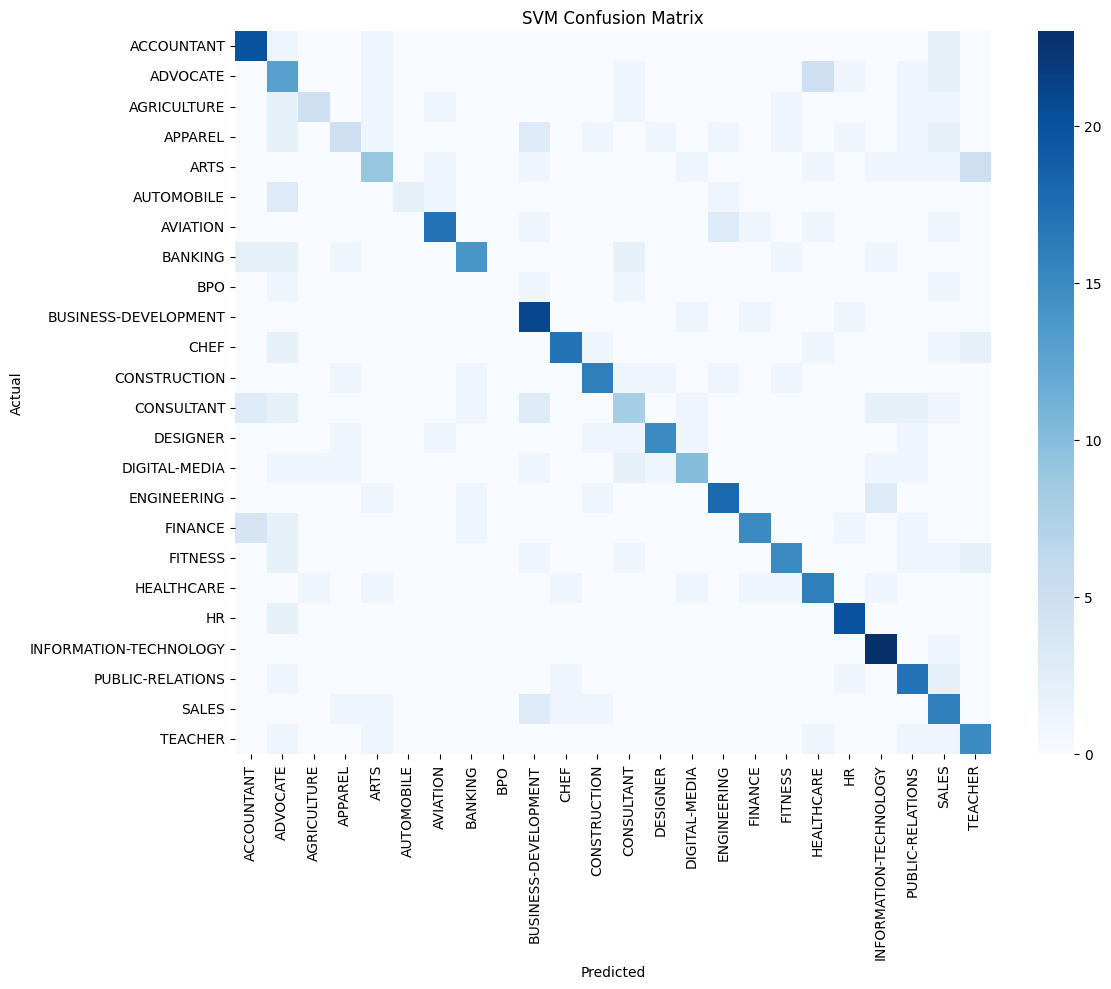

In [ ]:
# Visualize the SVM Confusion Matrix

plt.figure(figsize=(12,10))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png')
plt.show()

In [36]:
# Enable GPU and Install Required Libraries for BERT

!pip install -q transformers torch
import torch
print('GPU available:', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

GPU available: True


In [39]:
# Prepare the BERT Tokenizer, Dataset, and Model

from transformers import BertTokenizerFast, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

class ResumeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = ResumeDataset(X_train_raw, y_train, tokenizer)
test_dataset  = ResumeDataset(X_test_raw, y_test, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8)

bert_model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [40]:
# Fine-Tune the BERT Model

from torch.optim import AdamW
from tqdm import tqdm

optimizer = AdamW(bert_model.parameters(), lr=2e-5)
EPOCHS = 3

bert_model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = bert_model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1} average loss: {total_loss/len(train_loader):.4f}')

Epoch 1/3: 100%|██████████| 249/249 [01:52<00:00,  2.21it/s]


Epoch 1 average loss: 2.6167


Epoch 2/3: 100%|██████████| 249/249 [01:54<00:00,  2.17it/s]


Epoch 2 average loss: 1.1859


Epoch 3/3: 100%|██████████| 249/249 [01:52<00:00,  2.22it/s]

Epoch 3 average loss: 0.7480


In [41]:
# Evaluate the Fine-Tuned BERT Model

bert_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating'):
        labels = batch['labels'].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        outputs = bert_model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc_bert = accuracy_score(all_labels, all_preds)
prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
print(f'BERT -> Accuracy: {acc_bert:.4f} | Precision: {prec_b:.4f} | Recall: {rec_b:.4f} | F1: {f1_b:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Evaluating: 100%|██████████| 63/63 [00:14<00:00,  4.39it/s]

BERT -> Accuracy: 0.8008 | Precision: 0.7966 | Recall: 0.8008 | F1: 0.7919

                        precision    recall  f1-score   support

            ACCOUNTANT       0.96      1.00      0.98        24
              ADVOCATE       0.95      0.79      0.86        24
           AGRICULTURE       1.00      0.62      0.76        13
               APPAREL       0.37      0.37      0.37        19
                  ARTS       0.72      0.62      0.67        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.71      0.71      0.71        24
               BANKING       0.63      0.74      0.68        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.89      1.00      0.94        24
                  CHEF       0.87      0.83      0.85        24
          CONSTRUCTION       0.95      0.91      0.93        22
            CONSULTANT       0.96      0.96      0.96        23
              DESIGNER     


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/

In [42]:
# Compare the Performance of SVM and BERT Models

comparison = pd.DataFrame({
    'Model': ['SVM (ML)', 'BERT (DL)'],
    'Accuracy': [acc, acc_bert],
    'Precision': [prec, prec_b],
    'Recall': [rec, rec_b],
    'F1-score': [f1, f1_b]
})
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,SVM (ML),0.657948,0.669989,0.657948,0.650506
1,BERT (DL),0.800805,0.796632,0.800805,0.791865


In [43]:
comparison_pct = comparison.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    comparison_pct[col] = (comparison_pct[col] * 100).round(2).astype(str) + '%'
comparison_pct

,Model,Accuracy,Precision,Recall,F1-score
0,SVM (ML),65.79%,67.0%,65.79%,65.05%
1,BERT (DL),80.08%,79.66%,80.08%,79.19%


In [44]:
# Save the Trained Models and Output Files

import joblib, os
os.makedirs('models', exist_ok=True)
joblib.dump(svm_model, 'models/svm_model.pkl')
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

bert_model.save_pretrained('models/bert_resume_classifier')
tokenizer.save_pretrained('models/bert_resume_classifier')

!zip -r member3_outputs.zip models class_distribution.png length_distribution.png wordcloud.png svm_confusion_matrix.png
from google.colab import files
files.download('member3_outputs.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: models/ (stored 0%)
  adding: models/svm_model.pkl (deflated 36%)
  adding: models/bert_resume_classifier/ (stored 0%)
  adding: models/bert_resume_classifier/model.safetensors (deflated 7%)
  adding: models/bert_resume_classifier/config.json (deflated 65%)
  adding: models/bert_resume_classifier/tokenizer_config.json (deflated 43%)
  adding: models/bert_resume_classifier/tokenizer.json (deflated 71%)
  adding: models/label_encoder.pkl (deflated 32%)
  adding: models/tfidf_vectorizer.pkl (deflated 71%)
  adding: class_distribution.png (deflated 18%)
  adding: length_distribution.png (deflated 20%)
  adding: wordcloud.png (deflated 1%)
  adding: svm_confusion_matrix.png (deflated 17%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>